# Vérification de cohérence — `affluence_grand_plage_h_par_h_complet.csv`

Contrôles structurels et graphiques par colonne, pour repérer visuellement toute incohérence
avant publication (ruptures, valeurs aberrantes, non-respect des règles métier).
Voir le README du dépôt (section "Jeu open data affluence horaire") pour le contexte de
chaque colonne et les règles appliquées lors de la construction du fichier.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 3.5)

df = pd.read_csv("affluence_grand_plage_h_par_h_complet.csv")
df['date'] = pd.to_datetime(df['date'])
df['heure_h'] = pd.to_datetime(df['heure'], format='%H:%M:%S').dt.hour

METRIQUES = ['retours', 'prets', 'connexions_postes', 'connexions_wifi',
             'impressions', 'entrees', 'occupation']

print(f"{len(df)} lignes, du {df['date'].min().date()} au {df['date'].max().date()}")
df.head()

44948 lignes, du 2014-07-01 au 2026-08-30


,date,annee,jour,mois,heure,retours,prets,connexions_postes,connexions_wifi,impressions,entrees,occupation,heure_h
0,2014-07-01,2014,1,7,09:00:00,1,5,0,0,0,20,1,9
1,2014-07-01,2014,1,7,10:00:00,0,105,21,0,0,83,49,10
2,2014-07-01,2014,1,7,11:00:00,3,197,12,0,0,75,39,11
3,2014-07-01,2014,1,7,12:00:00,2,108,4,0,0,70,31,12
4,2014-07-01,2014,1,7,13:00:00,2,88,8,0,0,70,46,13


## 1. Vérifications structurelles

Tout ce qui suit doit afficher `0` (ou `True`) — un résultat différent signale une régression.

In [2]:
print("Doublons (date, heure)      :", df.duplicated(subset=['date', 'heure']).sum())

incoherence = (
    (df['jour'] != df['date'].dt.day)
    | (df['mois'] != df['date'].dt.month)
    | (df['annee'] != df['date'].dt.year)
)
print("Incohérences jour/mois/année :", incoherence.sum())

print("Valeurs manquantes (NaN)     :", df.isna().sum().sum())

for c in METRIQUES:
    print(f"Valeurs négatives ({c:<18}):", (df[c] < 0).sum())

tout_zero = (df[METRIQUES[:-1]] == 0).all(axis=1)  # occupation exclue : 0 y est légitime
print("\nLignes entièrement à zéro (hors occupation) :", tout_zero.sum())

Doublons (date, heure)      : 0
Incohérences jour/mois/année : 0
Valeurs manquantes (NaN)     : 0
Valeurs négatives (retours           ): 0
Valeurs négatives (prets             ): 0
Valeurs négatives (connexions_postes ): 0
Valeurs négatives (connexions_wifi   ): 0
Valeurs négatives (impressions       ): 0
Valeurs négatives (entrees           ): 0
Valeurs négatives (occupation        ): 0

Lignes entièrement à zéro (hors occupation) : 0


## 2. Règles métier

- Le lundi, la médiathèque est fermée au public : seuls les retours (boîte de retour) sont
  possibles, tout le reste doit être à `0`.
- Les prêts sont restreints à l'amplitude d'ouverture 9h-19h.

In [3]:
lundi = df[df['date'].dt.dayofweek == 0]
for c in ['prets', 'connexions_postes', 'connexions_wifi', 'impressions', 'entrees', 'occupation']:
    print(f"Lundi avec {c:<18} > 0 :", (lundi[c] > 0).sum())
print("Lundi avec retours > 0 (normal, seul flux autorisé) :", (lundi['retours'] > 0).sum())

hors_ouverture = (df['heure_h'] < 9) | (df['heure_h'] > 19)
print("\nPrêts hors 9h-19h :", (df.loc[hors_ouverture, 'prets'] > 0).sum())

Lundi avec prets              > 0 : 0
Lundi avec connexions_postes  > 0 : 0
Lundi avec connexions_wifi    > 0 : 0
Lundi avec impressions        > 0 : 0
Lundi avec entrees            > 0 : 0
Lundi avec occupation         > 0 : 0
Lundi avec retours > 0 (normal, seul flux autorisé) : 3967

Prêts hors 9h-19h : 0


## 3. Couverture temporelle

Nombre de lignes par année pour chaque métrique — permet de repérer d'un coup d'œil les
lacunes connues (wifi avant 2016, impressions avant 2015, `stat_issues` peu fiable avant 2019
sur la partie 2014-2020 reprise telle quelle du jeu publié à l'origine).

In [4]:
couverture = df.groupby(df['date'].dt.year)[METRIQUES].apply(lambda g: (g > 0).sum())
couverture.index.name = 'année'
couverture

,retours,prets,connexions_postes,connexions_wifi,impressions,entrees,occupation
année,,,,,,,
2014,1243,1196,940,0,0,905,720
2015,2682,2352,2012,0,553,1105,1032
2016,3483,2617,2550,1169,2166,2386,2336
2017,3623,2604,2500,2466,2369,2166,2128
2018,3437,2519,2449,2427,2375,2628,2430
2019,3671,2536,2434,2445,2373,1115,2414
2020,2004,2242,1605,1552,1566,540,1641
2021,3798,2342,2273,1925,2196,2388,2077
2022,3928,2579,2518,1593,2519,2628,2521


## 4. Séries temporelles mensuelles, par métrique

Pour repérer les ruptures, tendances et évènements exceptionnels (confinements, changements de capteur...).

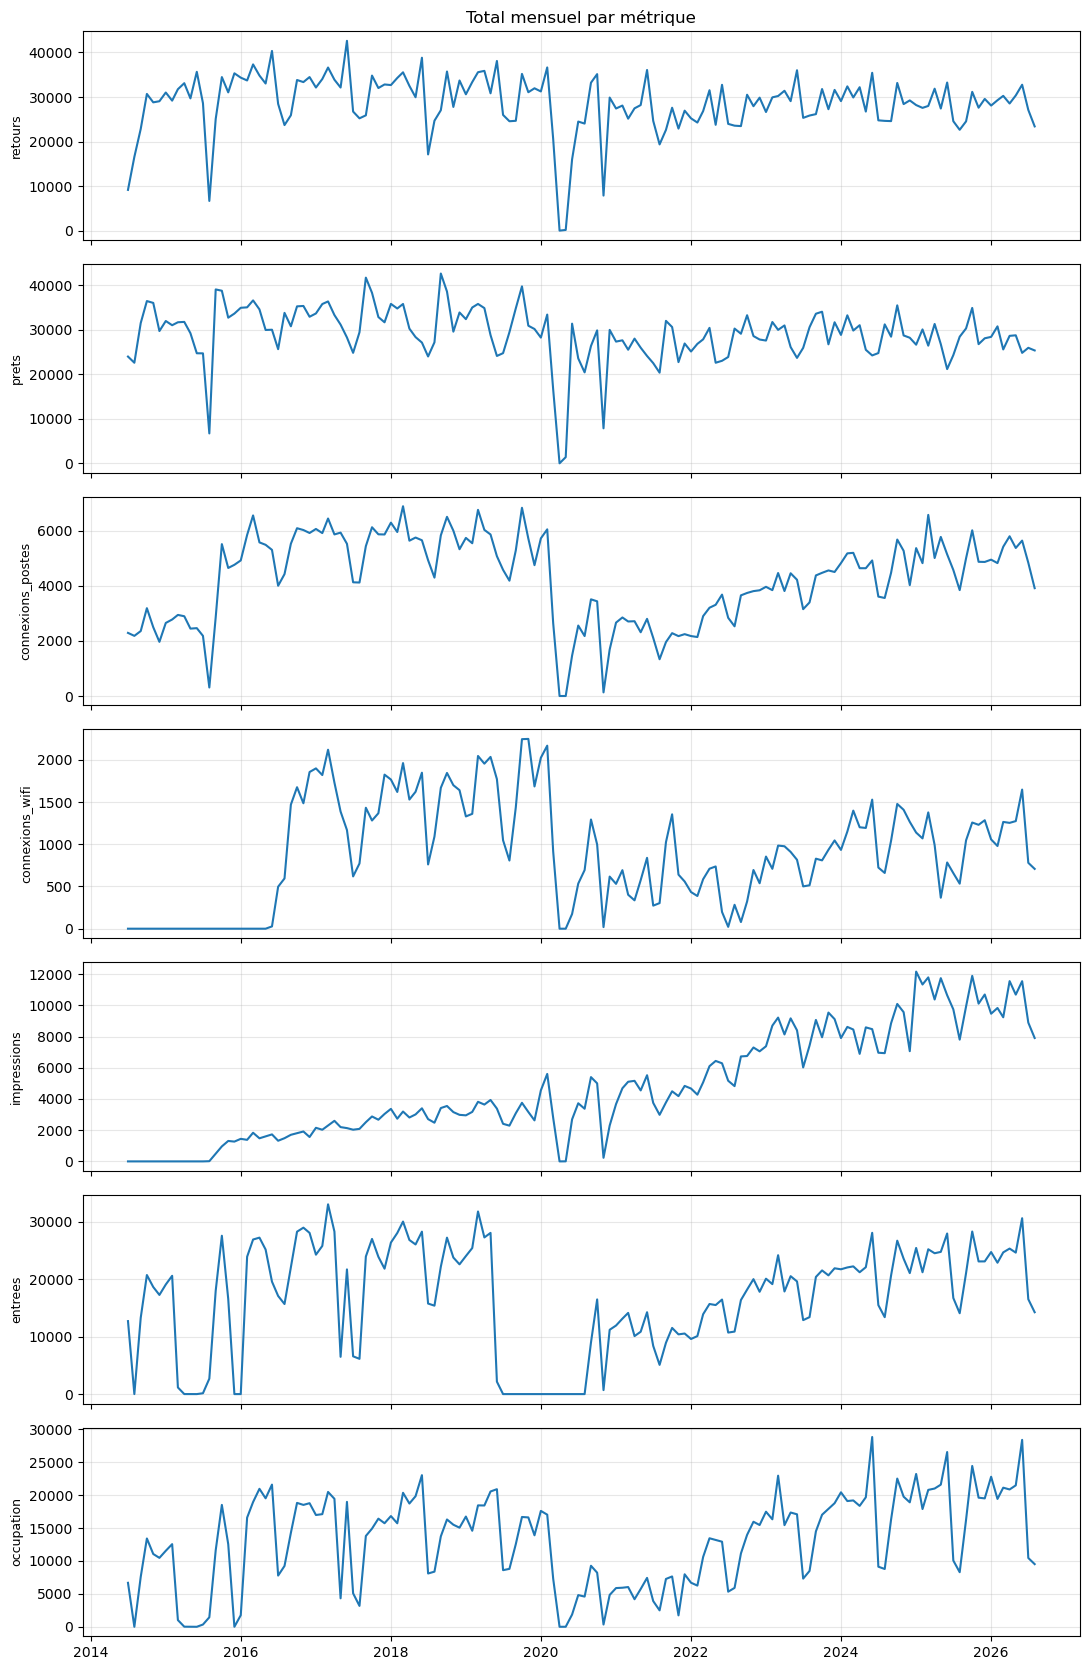

In [5]:
fig, axes = plt.subplots(len(METRIQUES), 1, figsize=(11, 2.4 * len(METRIQUES)), sharex=True)
mensuel = df.set_index('date')[METRIQUES].resample('MS').sum()
for ax, c in zip(axes, METRIQUES):
    ax.plot(mensuel.index, mensuel[c])
    ax.set_ylabel(c, fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_title("Total mensuel par métrique")
plt.tight_layout()
plt.show()

## 5. Profil horaire moyen

Doit dessiner une courbe en cloche cohérente avec l'amplitude d'ouverture (montée le matin,
pic en journée, descente en soirée) pour chaque métrique — un profil plat ou erratique
signalerait un problème.

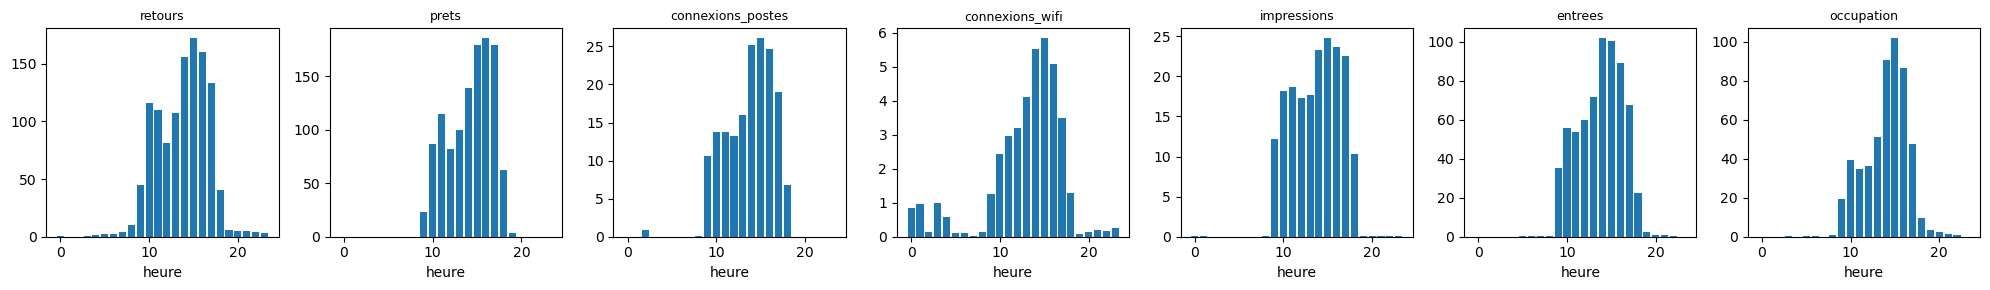

In [6]:
profil_horaire = df.groupby('heure_h')[METRIQUES].mean()

fig, axes = plt.subplots(1, len(METRIQUES), figsize=(20, 3), sharex=True)
for ax, c in zip(axes, METRIQUES):
    ax.bar(profil_horaire.index, profil_horaire[c])
    ax.set_title(c, fontsize=9)
    ax.set_xlabel("heure")
plt.tight_layout()
plt.show()

## 6. Profil par jour de la semaine

Le lundi doit ressortir proche de 0 pour tout sauf `retours` (règle métier appliquée à la
construction du fichier) - à vérifier visuellement ici.

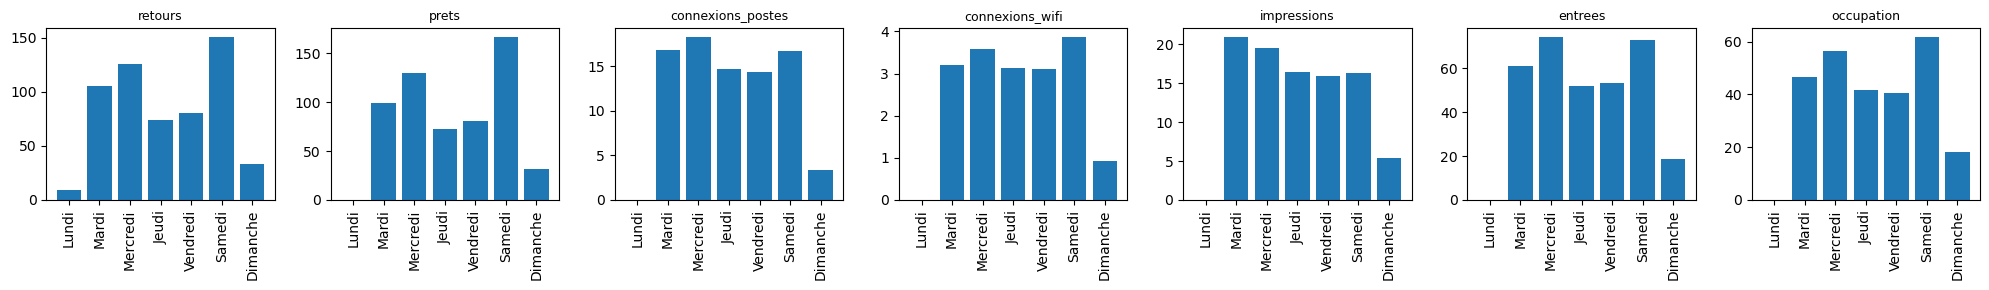

In [7]:
jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
profil_semaine = df.groupby(df['date'].dt.dayofweek)[METRIQUES].mean()
profil_semaine.index = jours

fig, axes = plt.subplots(1, len(METRIQUES), figsize=(20, 3))
for ax, c in zip(axes, METRIQUES):
    ax.bar(profil_semaine.index, profil_semaine[c])
    ax.set_title(c, fontsize=9)
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## 7. Distribution des valeurs

Repère les valeurs extrêmes (queue de distribution très longue = pics ponctuels à vérifier,
ex. confinements) et les colonnes majoritairement à 0 (normal pour connexions_wifi/impressions
avant leur date de démarrage réel).

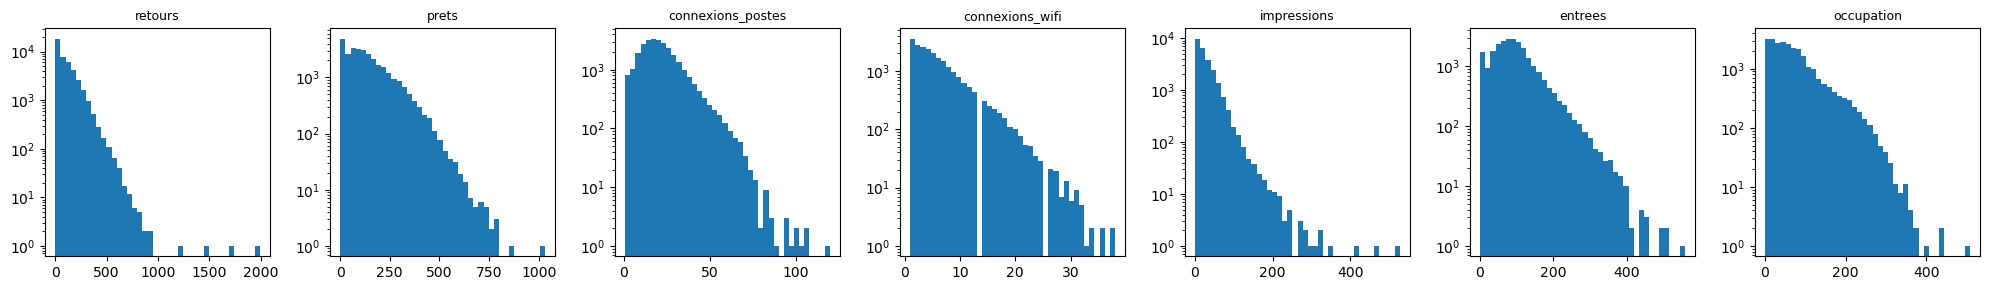

In [8]:
fig, axes = plt.subplots(1, len(METRIQUES), figsize=(20, 3))
for ax, c in zip(axes, METRIQUES):
    ax.hist(df[df[c] > 0][c], bins=40)
    ax.set_title(c, fontsize=9)
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 8. Focus `occupation` : forme d'une journée type

L'occupation doit dessiner une courbe qui monte à l'ouverture, varie dans la journée, et
redescend à 0 en fin de journée (voir README pour les cas où le dernier créneau *visible* du
fichier n'est pas exactement 0 - comportement documenté, pas un bug).

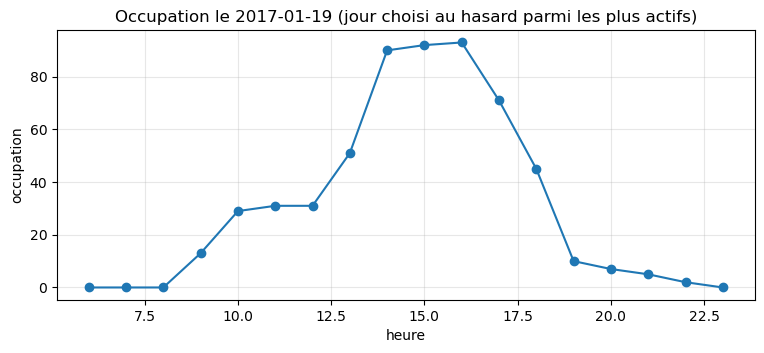

In [9]:
jour_type = df[(df['date'].dt.dayofweek.isin([1,2,3,4])) & (df['occupation'] > 0)]['date'].mode()
if len(jour_type):
    exemple = df[df['date'] == jour_type.iloc[0]].sort_values('heure_h')
    plt.figure(figsize=(9, 3.5))
    plt.plot(exemple['heure_h'], exemple['occupation'], marker='o')
    plt.title(f"Occupation le {jour_type.iloc[0].date()} (jour choisi au hasard parmi les plus actifs)")
    plt.xlabel("heure")
    plt.ylabel("occupation")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Aucun jour avec occupation > 0 trouvé.")

## 9. Corrélations entre métriques

Une cohérence d'ensemble : les métriques d'activité publique (retours, prêts, connexions,
impressions, entrées, occupation) devraient être globalement corrélées positivement entre
elles (mêmes heures/jours de forte fréquentation).

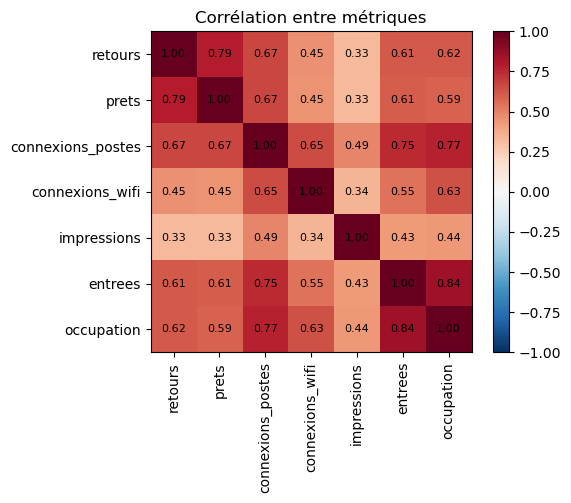

In [10]:
correlation = df[METRIQUES].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(correlation, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(METRIQUES)), METRIQUES, rotation=90)
ax.set_yticks(range(len(METRIQUES)), METRIQUES)
for i in range(len(METRIQUES)):
    for j in range(len(METRIQUES)):
        ax.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im)
plt.title("Corrélation entre métriques")
plt.tight_layout()
plt.show()